# Group 2: feature processing notebook

Этот ноутбук предназначен для исследовательской обработки признаков группы `2`.

Логика ячеек специально повторяет структуру `src/features/group_2/feature_processor.py`,
чтобы позже перенос был почти механическим.

In [216]:
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import sys

# путь до корня проекта
PROJECT_ROOT = Path("../../").resolve()

# добавляем в PYTHONPATH
sys.path.append(str(PROJECT_ROOT))

# теперь обычный импорт
#from src.utils.spec_converter import create_feature_spec_template
from src.utils.io import load_feature_names_from_txt

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

In [217]:
# Пути относительно папки notebooks/group_2/
DATA_PATH = Path("../../data/raw/clean_dataset.csv")
FEATURES_PATH = Path("../../data/feature_groups/features_group_2.txt")
OUTPUT_DIR = Path("../../notebook_outputs/group_2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
XSLX_PATH = Path("../../data/raw/PvzList_rus-2.xlsx")

In [218]:
df = pd.read_csv(DATA_PATH)
feature_names = load_feature_names_from_txt(FEATURES_PATH)
block_df = df[feature_names].copy()

print("Block shape:", block_df.shape)
for col in ["lead_Дата создания сделки", "lead_Дата получения денег на Р/С"]:
    block_df[col] = pd.to_datetime(block_df[col], unit="s")
display(block_df.head())

Block shape: (18887, 22)


C:\Users\Михаил\AppData\Local\Temp\ipykernel_13340\3199688270.py:1: DtypeWarning: Columns (79,80,81) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,row_id,contact_Код ПВЗ,lead_Вес (грамм)*,lead_Объявленная ценность (руб),lead_будущие покупки,lead_responsible_user_id,lead_Тариф Доставки,lead_Линейная длина (см),lead_utm_content,lead_Дата создания сделки,...,lead_FORMNAME,outcome_unknown,lead_Дата получения денег на Р/С,lead_utm_group,lead_utm_referrer,lead_roistat,lead_tags,lead_utm_source,contact_responsible_user_id,lead_Квалификация лида
0,0,NaN,NaN,NaN,NaN,MGR_0001,NaN,NaN,116543546_5520577031_16700367732_type1_mobile_glavny.tv_none_0_53871621623_Ставропольский край,NaT,...,NaN,False,2025-03-19 21:00:00,yur,https://insult.npotpz.ru/sleep,RST_2301,"tilda,yur",ppc_ru_yandex_art_npz,MGR_0001,NaN
1,1,MSK2348,NaN,NaN,NaN,MGR_0002,NaN,NaN,116057578_5515271477_16779908314_type1_mobile_ru.mail.mailapp_none_0_53729902618_Москва,NaT,...,NaN,False,2025-03-17 21:00:00,yur,NaN,RST_2311,npotpz.ru,ppc_ru_yandex_art_npz,MGR_0017,NaN
2,2,NaN,NaN,NaN,NaN,MGR_0001,NaN,NaN,115509254_5508305475_16624953471_type1_mobile_m.dzen.ru_none_0_53533827021_Владивосток,NaT,...,NaN,False,2025-03-25 21:00:00,yur,NaN,RST_2309,"npotpz.ru,yur",ppc_ru_yandex_art_npz,MGR_0001,NaN
3,3,"ул. Гвардейская, 18В",NaN,NaN,NaN,MGR_0002,NaN,NaN,NaN,NaT,...,NaN,False,2025-03-17 21:00:00,NaN,NaN,NaN,"Baza ARTRAID,23.02.25-25%",NaN,MGR_0030,NaN
4,4,NaN,NaN,NaN,NaN,MGR_0001,NaN,NaN,114252495_5492374363_16498717408_type1_desktop_dzen.ru_none_0_53042383361_Астрахань,NaT,...,NaN,False,2025-03-16 21:00:00,yur,https://npotpz.ru/landing-artraid/,RST_2323,Callibri,ppc_ru_yandex_art_npz,MGR_0001,NaN


In [219]:
block_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   row_id                            18887 non-null  int64         
 1   contact_Код ПВЗ                   13033 non-null  object        
 2   lead_Вес (грамм)*                 12120 non-null  float64       
 3   lead_Объявленная ценность (руб)   3112 non-null   float64       
 4   lead_будущие покупки              12328 non-null  object        
 5   lead_responsible_user_id          18887 non-null  object        
 6   lead_Тариф Доставки               17806 non-null  object        
 7   lead_Линейная длина (см)          3147 non-null   float64       
 8   lead_utm_content                  12567 non-null  object        
 9   lead_Дата создания сделки         8286 non-null   datetime64[ns]
 10  contact_LTV                       13961 non-nu

In [220]:
# Считаем количество строк, где значения совпадают (NaN != NaN)
matches = (
    block_df["lead_responsible_user_id"]
    == block_df["contact_responsible_user_id"]
).sum()
total_rows = len(block_df)

print(
    f"Совпадают {matches} из {total_rows} строк ({matches / total_rows:.2%})"
)

Совпадают 13293 из 18887 строк (70.38%)


In [221]:
# Создаём признак: сначала проверяем совпадение значений
same_values = (
    block_df["lead_responsible_user_id"] == block_df["contact_responsible_user_id"]
)

# Находим строки с пропусками во втором столбце
contact_missing = block_df["contact_responsible_user_id"].isna()

# Объединяем условия: совпадение ИЛИ пропуск во втором столбце = 1, иначе 0
block_df["is_responsible_same"] = (same_values | contact_missing).astype(int)

In [222]:
block_df = block_df.drop(columns=["lead_Объявленная ценность (руб)", "lead_Линейная длина (см)"])

In [223]:
for col in ["lead_Вес (грамм)*", "contact_LTV"]:
    q1 = block_df[col].quantile(0.25)
    q3 = block_df[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5*iqr
    outliers = (block_df[col] < lower) | (block_df[col] > upper)
    res = outliers.sum()
    print(f"Для признака {col} процент выбросов: {(res / len(block_df)) * 100:.2f}%")
    median = block_df[col].median()
    block_df.loc[(block_df[col] < lower) | (block_df[col] > upper), col] = median

Для признака lead_Вес (грамм)* процент выбросов: 3.63%
Для признака contact_LTV процент выбросов: 7.83%


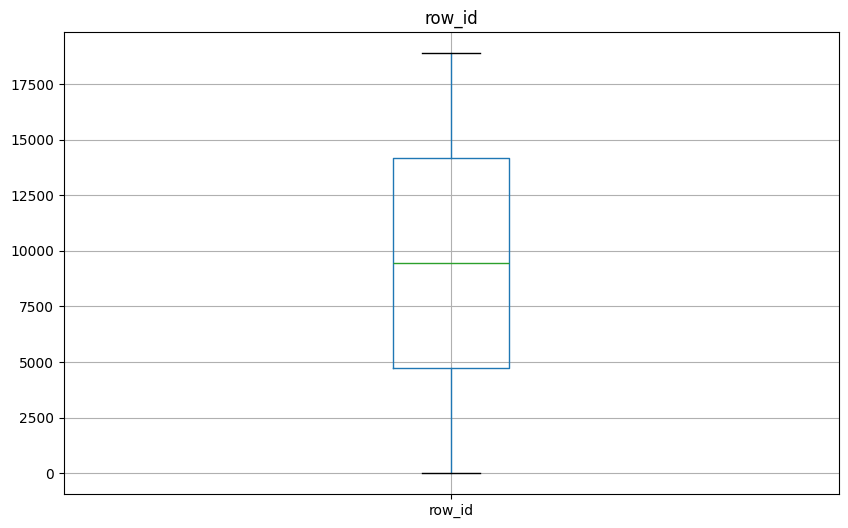

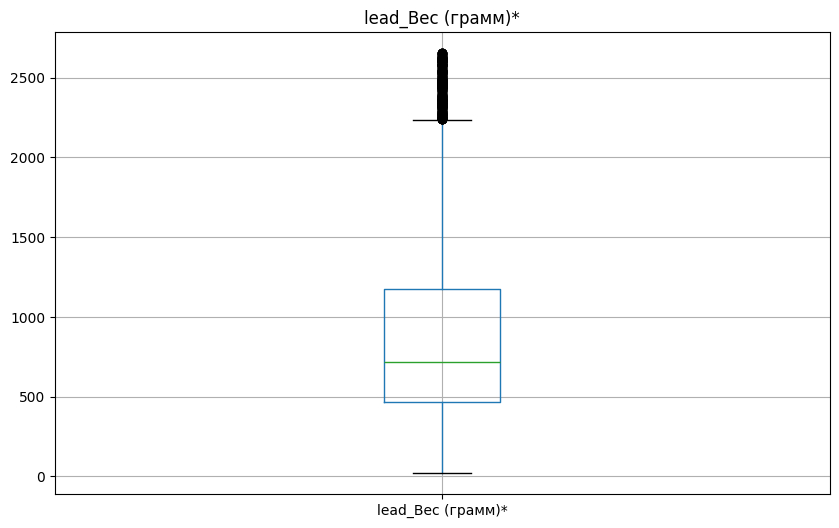

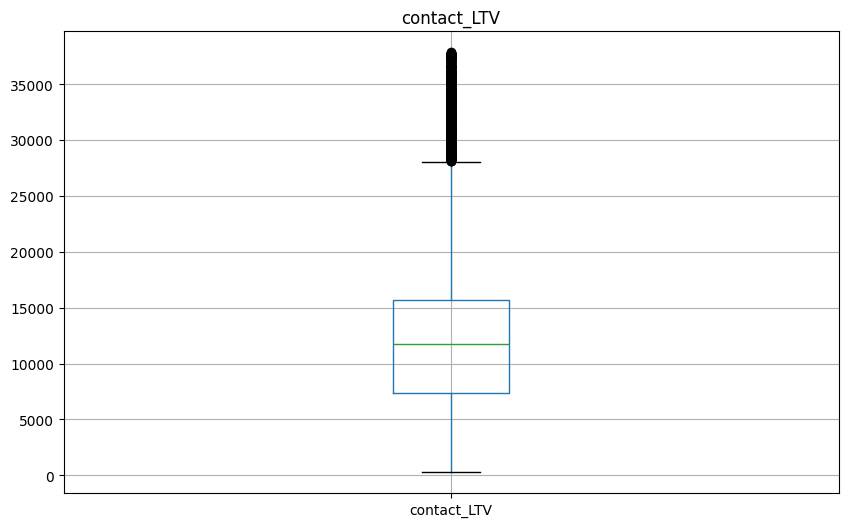

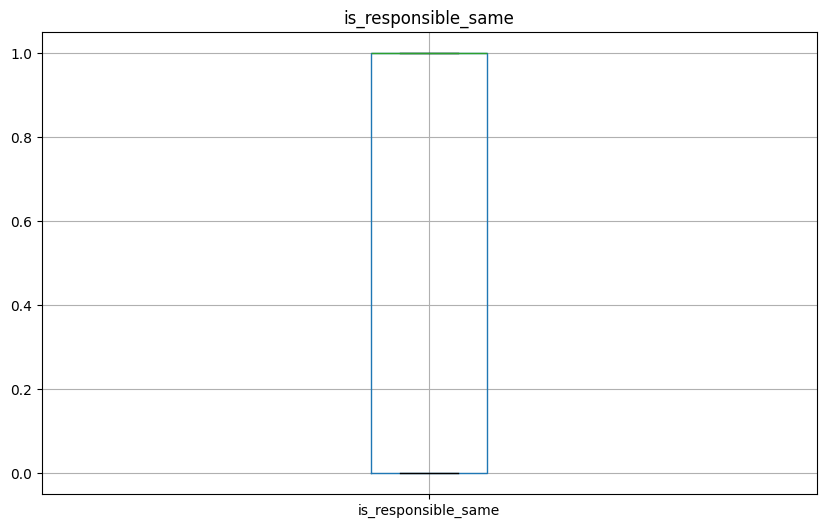

In [224]:
numeric_cols = block_df.select_dtypes(include=["number"]).columns
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    block_df[[col]].boxplot()
    plt.title(col)
    plt.show()

<Figure size 1000x600 with 0 Axes>

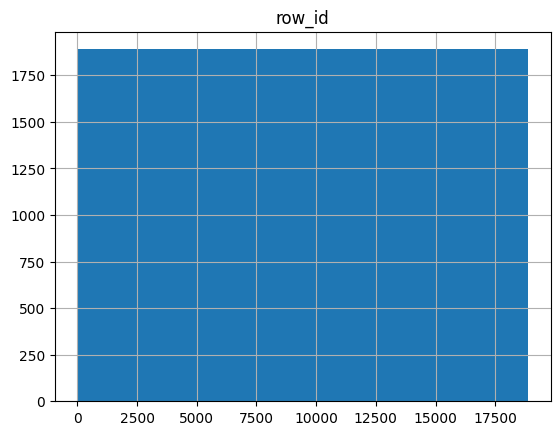

<Figure size 1000x600 with 0 Axes>

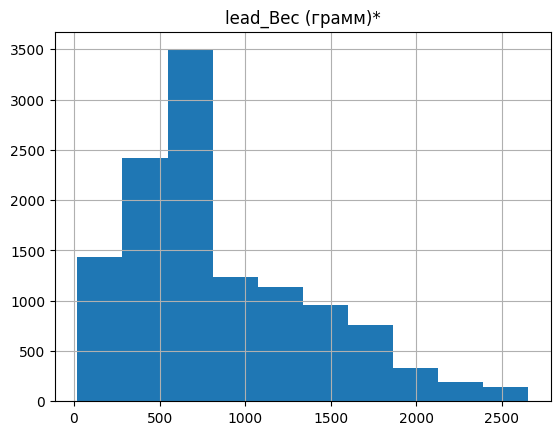

<Figure size 1000x600 with 0 Axes>

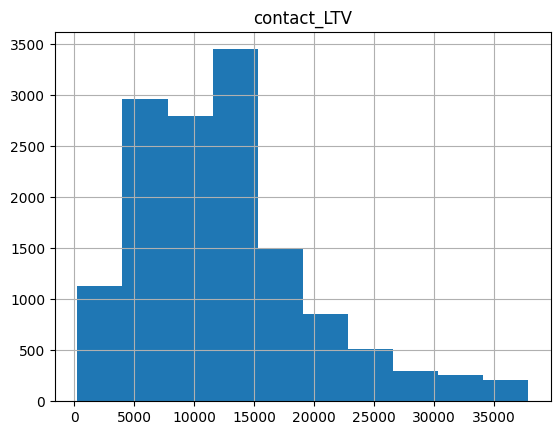

<Figure size 1000x600 with 0 Axes>

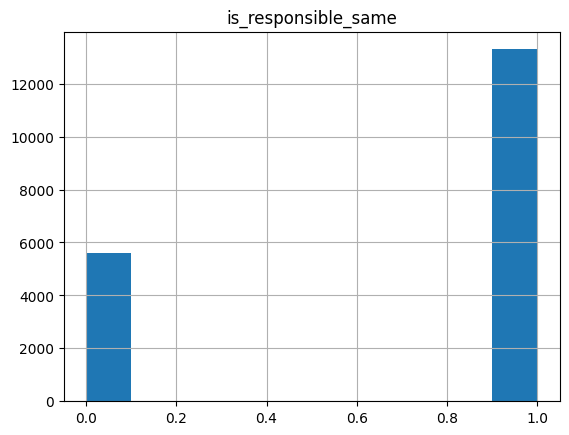

In [225]:
numeric_cols = block_df.select_dtypes(include=["number"]).columns
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    block_df[[col]].hist()
    plt.title(col)
    plt.show()

In [226]:
for col in ["lead_Вес (грамм)*", "contact_LTV"]:
    res = block_df[col].isna().sum()
    print(f"Для признака {col} процент пропусков: {(res / len(block_df)) * 100:.2f}%")

Для признака lead_Вес (грамм)* процент пропусков: 35.83%
Для признака contact_LTV процент пропусков: 26.08%


In [227]:
# Заполняем пропуски для 'lead_Вес (грамм)*'
block_df["has_weight"] = np.where(block_df["lead_Вес (грамм)*"].isna(), 0, 1)
block_df["lead_Вес (грамм)*"] = block_df["lead_Вес (грамм)*"].fillna(-1)

# Заполняем пропуски в contact_LTV
block_df["has_contact_LTV"] = np.where(block_df["contact_LTV"].isna(), 0, 1)
block_df["contact_LTV"] = block_df["contact_LTV"].fillna(-1)

In [228]:
block_df["sale_date"] = block_df["sale_date"].astype("datetime64[ns]")

In [229]:
str_cols = block_df.select_dtypes(include=["object"], exclude=["datetime64[ns]"]).columns
for col in str_cols:
    print(f"Уникальные значения {col}:")
    print(list(block_df[col].unique()))
    print()

Уникальные значения contact_Код ПВЗ:
[nan, 'MSK2348', 'ул. Гвардейская, 18В', 'KRK3', 'ул. Ленина, 72Б (KMN5)', 'ул. Маршала Рыбалко, 9, пом.2 (MSK163)', 'ул. Институтская, 15', 'ул. Профсоюзная, 102А, этаж -1 (MSK599)', 'SPB24', 'Проспект Победы, 19а (KUR14)', 'Восточная ул., 11', 'ABK14', 'SPB23', 'ул. Подмосковная, 35 (OSTS5)', 'ул. 8 марта, 29', 'ул. Советская, 50', 'NKHD3', 'мкр-н Аверьянова, 12 (DMT3)', 'ул. Энергетиков, 2 (ZLG2)', 'ул. Ленина, 117 (BLK9)', 'пр-т Ленина, 37/73', 'ул. Федерации, 52', 'ул. Николая Ершова, д. 62Д, к.2 (KZN35)', 'ул. Ленина, 50 (BLK6)', 'пр-т. Новочеркасский, 33, корп. 3 (SPB1155)', 'SCH37', 'пр-т Красного Знамени, 34', 'ул. Просвещения, 104', 'Бакунинская ул., 23-41', 'ул. Пушкина, 6/8н', 'VLG49', 'ул. Косарева, 103А', 'до двери', 'ул. Амундсена, 56А, 1', 'ул. Атарбекова, 4а (MSK449)', 'USS1', 'ул. Орджоникидзе, 52', 'Варшавское шоссе, вл. 132/2 (MSK1124)', 'ул. Первомайская, 165', 'ул. Пролетарская, 231', 'Народный бульвар, 15 (RZN9)', 'Название: у

In [230]:
def exctract_code_pvz(value):
    if pd.isna(value):
        return value
    match = re.fullmatch(r".*?([A-Z]+\d+).*", str(value))
    if match:
        return match.group(1)
    return value


def replace_non_matching(series):
    if not isinstance(series, pd.Series):
        series = pd.Series(series)
    pattern = re.compile(r"^([A-Z]+)\d+$")
    result = []
    for value in series:
        if pd.isna(value):
            result.append("unknown")
        else:
            match = pattern.match(str(value).strip())
            if match:
                result.append(match.group(1))
            else:
                result.append("HOME")
    return pd.Series(result, index=series.index)

In [231]:
block_df["contact_Код ПВЗ"] = [exctract_code_pvz(x) for x in block_df["contact_Код ПВЗ"]]
block_df["contact_Код ПВЗ"] = replace_non_matching(block_df["contact_Код ПВЗ"])

# Для всех значений в contact_Код ПВЗ которые не являются кодом ПВЗ будет установлено значение HOME 0

# Для всех остальных nan значений в код ПВЗ будет установлено значение unknown

In [232]:
pvz_data = pd.read_excel(XSLX_PATH, sheet_name="Россия", usecols=[0, 1, 2], engine='openpyxl')

display(pvz_data.head())

,Регион,Город,Код
0,Адыгея,Адыгейск,ADY3
1,Адыгея,Гиагинская,GIG1
2,Адыгея,"Каменномостский, Майкопский район",KAM49
3,Адыгея,Майкоп,MAY3
4,Адыгея,Майкоп,MAY1


In [233]:
def expand_cities_by_comma(pvz_data: pd.DataFrame) -> pd.DataFrame:
    expanded_rows = []
    for idx, row in pvz_data.iterrows():
        city = row["Город"]
        if "," in str(city):
            cities = [c.strip() for c in str(city).split(",")]
            for single_city in cities:
                new_row = row.copy()
                new_row["Город"] = single_city
                expanded_rows.append(new_row)
        else:
            expanded_rows.append(row)

    result_df = pd.DataFrame(expanded_rows)
    result_df = result_df.drop_duplicates()
    return result_df.reset_index(drop=True)

In [234]:
pvz_data = expand_cities_by_comma(pvz_data)

pvz_dict = {}
for pvz_code, region in zip(pvz_data.iloc[:, 2], pvz_data.iloc[:, 0]):
    match = re.match(r"^([A-Z]+)", str(pvz_code))
    if match:
        pvz_dict[match.group(1)] = region


def get_region(code):
    if code == "HOME":
        return "no_pvz"
    if pd.isna(code) or code == "unknown":
        return "unknown"
    region = pvz_dict.get(code, "unknown")
    if region == "unknown":
        return "unknown"
    return region

In [235]:
block_df["contact_region_pvz"] = block_df["contact_Код ПВЗ"].apply(get_region)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'unknown'),
  Text(1, 0, 'Москва'),
  Text(2, 0, 'no_pvz'),
  Text(3, 0, 'Московская область'),
  Text(4, 0, 'Санкт-Петербург'),
  Text(5, 0, 'Ульяновская область'),
  Text(6, 0, 'Краснодарский край'),
  Text(7, 0, 'Ростовская область'),
  Text(8, 0, 'Свердловская область'),
  Text(9, 0, 'Челябинская область'),
  Text(10, 0, 'Саратовская область'),
  Text(11, 0, 'Татарстан'),
  Text(12, 0, 'Ханты-Мансийский автономный округ - Югра'),
  Text(13, 0, 'Красноярский край'),
  Text(14, 0, 'Нижегородская область')])

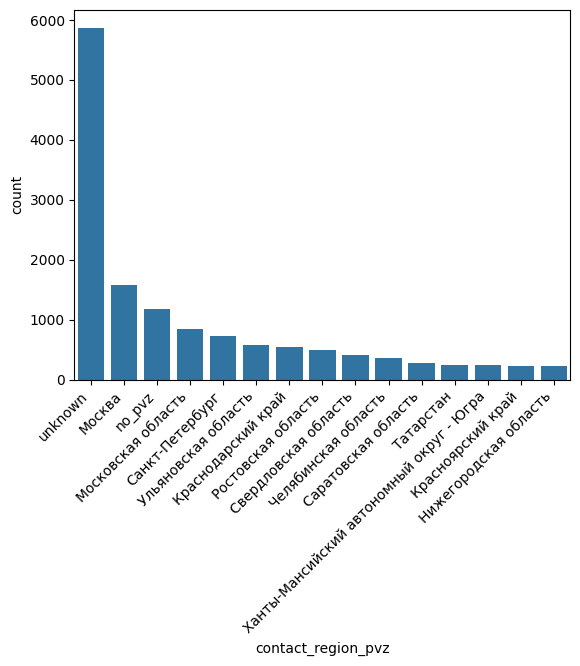

In [236]:
top_15 = block_df["contact_region_pvz"].value_counts().nlargest(15).index
sns.countplot(x=block_df["contact_region_pvz"], order=top_15)
plt.xticks(rotation=45, ha="right")

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'dem'),
  Text(1, 0, 'unknown'),
  Text(2, 0, 'yur'),
  Text(3, 0, 'nim'),
  Text(4, 0, 'but'),
  Text(5, 0, 'gus'),
  Text(6, 0, 'inr'),
  Text(7, 0, 'ut'),
  Text(8, 0, 'imp'),
  Text(9, 0, 'kru'),
  Text(10, 0, 'nil'),
  Text(11, 0, 't'),
  Text(12, 0, 'mea'),
  Text(13, 0, 'gn')])

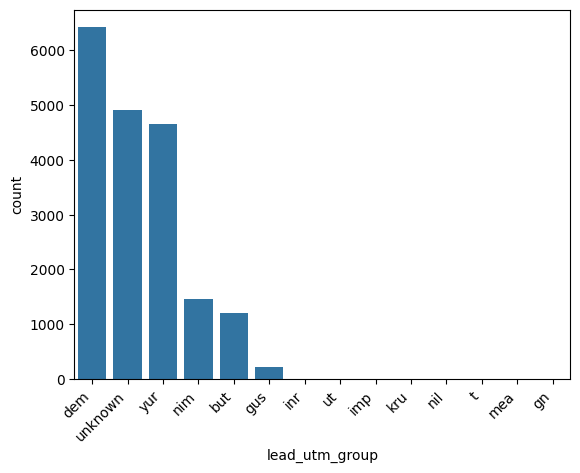

In [237]:
def clean_utm_group(value):
    # Если значение не строка или пустое — возвращаем 'unknown'
    if not isinstance(value, str) or not value:
        return "unknown"

    # Ищем первый небуквенный символ
    match = re.search(r"[^a-zA-Z]", value)

    if match:
        # Обрезаем до первого небуквенного символа
        cleaned = value[: match.start()]
        # Если после обрезки получилось пустое значение — возвращаем 'unknown'
        return cleaned if cleaned else "unknown"
    else:
        # Если строка состоит только из букв — возвращаем её как есть
        return value


# Применяем функцию к столбцу
block_df["lead_utm_group"] = block_df["lead_utm_group"].apply(clean_utm_group)
top_15 = block_df["lead_utm_group"].value_counts().nlargest(15).index
sns.countplot(x=block_df["lead_utm_group"], order=top_15)
plt.xticks(rotation=45, ha="right")

<Axes: xlabel='lead_utm_group', ylabel='count'>

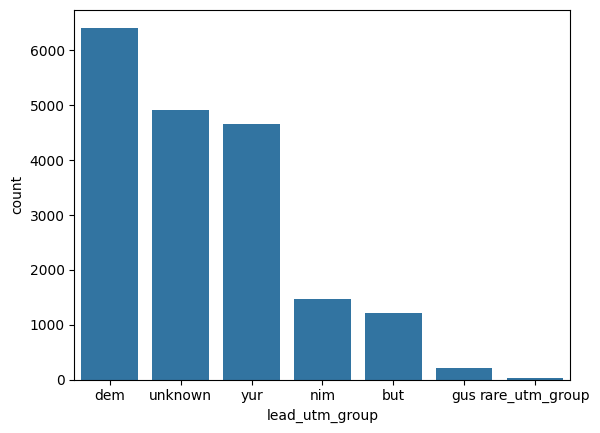

In [238]:
# Получаем топ-5 самых частых значений (исключая 'unknown')
top_5 = (
    block_df[block_df["lead_utm_group"] != "unknown"]["lead_utm_group"]
    .value_counts()
    .head(5)
    .index.tolist()
)

mask = ~block_df["lead_utm_group"].isin(top_5) & (
    block_df["lead_utm_group"] != "unknown"
)

block_df.loc[mask, "lead_utm_group"] = "rare_utm_group"
block_df["lead_utm_group"] = block_df["lead_utm_group"].fillna("unknown")
sns.countplot(
    block_df,
    x=block_df["lead_utm_group"],
    order=block_df["lead_utm_group"].value_counts().index,
)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'https://artraid-dem.ru/varikoz_clip4'),
  Text(1, 0, 'https://artraid-dem.ru/otek_clip4'),
  Text(2, 0, 'https://artraid-dem.ru/sustav_clip4'),
  Text(3, 0, 'https://insult.npotpz.ru/sleep'),
  Text(4, 0, 'https://artraid-dem.ru/sleep-clip3'),
  Text(5, 0, 'https:///Неизвестно'),
  Text(6, 0, 'https://npotpz.ru/landing-artraid/'),
  Text(7, 0, 'https://poyasnica.npotpz.ru/'),
  Text(8, 0, 'https://artraid.website/varikoz_clip4'),
  Text(9, 0, 'https://artraide.pro/varikoz_clip4'),
  Text(10, 0, 'https://npotpz.ru/landing-artraid-2/'),
  Text(11, 0, 'https://artraide.pro/sleep'),
  Text(12, 0, 'https://artraid.website/landing-artraid-2'),
  Text(13, 0, 'https://artraide.pro/landing-artraid-2'),
  Text(14, 0, 'https://artraid.website/landing-artraid-warm1')])

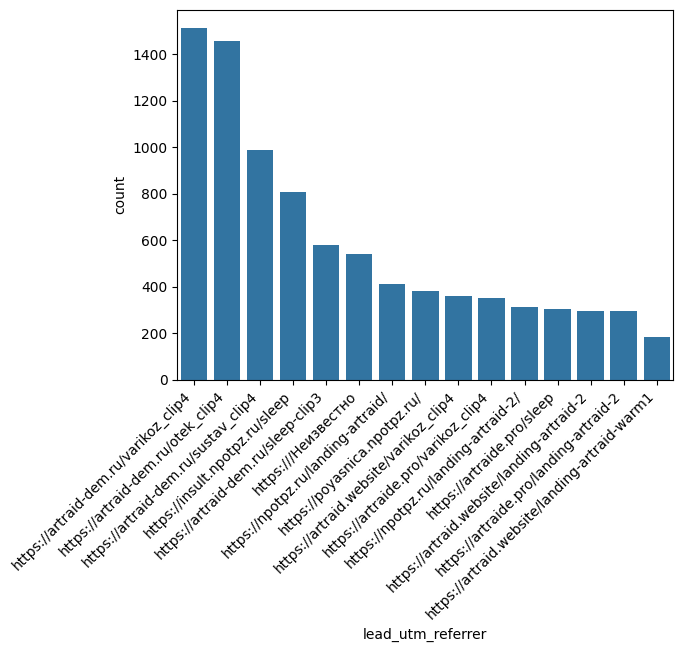

In [239]:
top_15 = block_df["lead_utm_referrer"].value_counts().nlargest(15).index
sns.countplot(x=block_df["lead_utm_referrer"], order=top_15)
plt.xticks(rotation=45, ha="right")

In [240]:
# Функция для определения категории сайта
def get_site_category(url):
    if pd.isna(url) or not url:
        return "unknown"

    url_lower = url.lower()
    if "artraid" in url_lower:
        return "artraid"
    elif "npotpz" in url_lower:
        return "npotpz"
    else:
        return "other"


# Создаём новый признак с категорией сайта
block_df["lead_utm_referrer_site"] = block_df["lead_utm_referrer"].apply(
    get_site_category
)

# Обновляем lead_utm_referrer: берём часть строки до первого '/' с конца
block_df["lead_utm_referrer"] = block_df["lead_utm_referrer"].apply(
    lambda x: x.rsplit("/", 1)[1] if isinstance(x, str) and x else x
)

# Проверка результата
print("Распределение категорий в новом признаке:")
print(block_df["lead_utm_referrer_site"].value_counts())
print("Распределение категорий в старом признаке:")
print(block_df["lead_utm_referrer"].value_counts())


Распределение категорий в новом признаке:
lead_utm_referrer_site
artraid    9047
unknown    7642
npotpz     1599
other       599
Name: count, dtype: int64
Распределение категорий в старом признаке:
lead_utm_referrer
varikoz_clip4                        2601
                                     1791
otek_clip4                           1489
sustav_clip4                         1180
sleep                                1113
sleep-clip3                           684
landing-artraid-2                     588
Неизвестно                            541
landing-artraid-warm1                 184
landing-artraid                       165
davlenie2_3                           165
varikoz_clip                           97
varikoz_clip_price4                    87
sustav2_clip3                          84
thanks                                 78
ssz                                    48
davlenie2_2                            39
artraid_davlenie                       37
lec_sv                      

In [241]:
# Список целевых категорий для поиска
categories = ["varikoz", "otek", "sustav", "sleep", "davlenie"]


def extract_category(value):
    # Обработка пропусков и нестроковых значений
    if not isinstance(value, str) or not value:
        return "unknown"

    # Приводим к нижнему регистру для корректного поиска
    value_lower = value.lower()

    # Ищем первую подходящую категорию в списке
    for category in categories:
        if category in value_lower:
            return category

    # Если ни одна категория не найдена — возвращаем 'other'
    return "other"


# Применяем функцию к столбцу
block_df["lead_utm_referrer"] = block_df["lead_utm_referrer"].apply(
    extract_category
)

# Проверка результата
print("Распределение категорий после обработки:")
print(block_df["lead_utm_referrer"].value_counts())

Распределение категорий после обработки:
lead_utm_referrer
unknown     9433
varikoz     2839
sleep       1821
other       1716
otek        1520
sustav      1308
davlenie     250
Name: count, dtype: int64


In [242]:
block_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   row_id                            18887 non-null  int64         
 1   contact_Код ПВЗ                   18887 non-null  object        
 2   lead_Вес (грамм)*                 18887 non-null  float64       
 3   lead_будущие покупки              12328 non-null  object        
 4   lead_responsible_user_id          18887 non-null  object        
 5   lead_Тариф Доставки               17806 non-null  object        
 6   lead_utm_content                  12567 non-null  object        
 7   lead_Дата создания сделки         8286 non-null   datetime64[ns]
 8   contact_LTV                       18887 non-null  float64       
 9   sale_date                         18887 non-null  datetime64[ns]
 10  lead_FORMNAME                     7571 non-nul

In [243]:
block_df["lead_has_roistat"] = np.where(block_df["lead_roistat"].isna(), 0, 1)
block_df = block_df.drop(columns=["lead_roistat"])

In [244]:
block_df["lead_tags"].value_counts().nlargest(15).index

Index(['tilda', 'npotpz.ru,yur', 'Callibri,yur', 'tilda,B-лид', 'npotpz.ru',
       'Callibri', 'ВХОДЯЩИЙ', 'tilda,А-лид', 'tilda,but', 'tilda,yur',
       'artraid', 'tilda,otek_clip', 'tilda,varikoz_clip',
       'Промокод ARTRAID15', 'ВХОДЯЩИЙ,органик'],
      dtype='object', name='lead_tags')

In [245]:
# Список целевых категорий
categories = ["tilda", "npotpz", "Callibri", "ВХОДЯЩИЙ", "artraid"]


def categorize_tags(value):
    # Если значение не заполнено (NaN, None, пустая строка) — возвращаем 'unknown'
    if not isinstance(value, str) or not value:
        return "unknown"

    value_lower = value.lower()

    # Проверяем наличие каждой категории в строке
    for category in categories:
        if category.lower() in value_lower:
            return category
    # Если ни одна категория не найдена — возвращаем 'unknown'
    return "unknown"


# Применяем функцию к столбцу
block_df["lead_tags"] = block_df["lead_tags"].apply(categorize_tags)

# Проверка результата
print("Распределение категорий после обработки:")
print(block_df["lead_tags"].value_counts())

Распределение категорий после обработки:
lead_tags
tilda       8120
npotpz      2935
Callibri    2678
unknown     2021
ВХОДЯЩИЙ    1748
artraid     1385
Name: count, dtype: int64


In [246]:
block_df["lead_utm_source"].value_counts()

lead_utm_source
ppc_ru_yandex_art_npz          6619
ppc_ru_yandex_otek_dem         1645
ppc_ru_yandex_varikoz_dem      1178
ppc_ru_yandex_sustav_dem        962
ppc_ru_yandex_sleep_dem         632
Неизвестно                      547
ppc_ru_yandex_davlenie2_dem     178
ppc_ru_yandex_ssz_dem           173
ppc_ru_yandex_otek_dem7         135
ppc_ru_yandex_varikoz_dem2      123
yandex                          116
ppc_ru_yandex_sustav2_dem        98
ppc_ru_yandex_doctor-sv_dem      72
abdm                             32
Youtube                          25
solo                             13
sma_ru_vkontakte_art_npz          9
ppc_ru_yandex_sustav_dem7         8
ppc_ru_yandex_davlenie_dem        7
yandex.promopages                 4
priamoiperehoduis                 4
priamoiperehoduis2                3
ppc_ru_yandex_otek_dem2           3
yur-bot-varikoz-2                 2
ppc_ru_yandex_otek2_dem           2
yandexsmartcamera                 1
Name: count, dtype: int64

In [247]:
# Получаем топ‑5 самых частых значений
top_5 = block_df["lead_utm_source"].value_counts().head(5).index.tolist()


# Заменяем «Неизвестно» на «unknown»
block_df["lead_utm_source"] = block_df["lead_utm_source"].replace(
    "Неизвестно", "unknown"
)


# Заменяем все значения, не входящие в топ‑5 и не равные 'unknown', на 'rare_utm_source'
mask = ~block_df["lead_utm_source"].isin(top_5) & (
    block_df["lead_utm_source"] != "unknown"
)
block_df.loc[mask, "lead_utm_source"] = "rare_utm_source"


# Обрабатываем пропуски (NaN) — заменяем на «unknown»
block_df["lead_utm_source"] = block_df["lead_utm_source"].fillna("unknown")


# Проверка результата
print("Распределение после обработки:")
print(block_df["lead_utm_source"].value_counts())


Распределение после обработки:
lead_utm_source
rare_utm_source              7304
ppc_ru_yandex_art_npz        6619
ppc_ru_yandex_otek_dem       1645
ppc_ru_yandex_varikoz_dem    1178
ppc_ru_yandex_sustav_dem      962
ppc_ru_yandex_sleep_dem       632
unknown                       547
Name: count, dtype: int64


In [248]:
block_df["lead_Квалификация лида"] = block_df["lead_Квалификация лида"].fillna(
    "unknown"
)
block_df["lead_Квалификация лида"].value_counts()

lead_Квалификация лида
А - лид       6675
unknown       6563
В - лид       3455
С - лид       1991
Неквал лид     179
D - лид         20
Е - лид          4
Name: count, dtype: int64

In [249]:
def split_utm_content(series):
    def parse_utm(value):
        value = str(value)
        parts = value.split("_")
        if len(parts) == 10:
            return parts
        else:
            return ["unknown"] * 10

    split_data = series.apply(parse_utm).apply(pd.Series)
    split_data.columns = [f"utm_{i + 1}" for i in range(10)]
    return split_data

In [250]:
def print_analytics_per_columns(df: pd.DataFrame, columns: list[str]) -> None:
    for col in columns:
        unique_values = df[col].dropna().unique()
        numeric_mask = pd.to_numeric(
            pd.Series(unique_values), errors="coerce"
        ).notna()
        numeric_count = numeric_mask.sum()
        string_count = len(unique_values) - numeric_count
        print(f"Признак {col}: {numeric_count} числовых, {string_count} строковых")  

Информация о utm метках:

utm1 = {some_id_1} (ex. 67fe9a8c08ba1e2eb4b4aed1)

utm2 = {some_id_2} (ex. 67fe9b1ed81a5d71631f34c0)

utm3 = {some_id_3} (ex. 67fe9b1ed81a5d71631f34c0)

utm4 = {campaign_type}

utm5 = {device_type}

utm6 = {site} (ex. dzen.ru)

utm7 = {position_type}

utm8 = {position}

utm9 = {retargeting_id}

utm10 = {region_name}

In [251]:
utm_parsed = split_utm_content(block_df["lead_utm_content"])
block_df = pd.concat([block_df, utm_parsed], axis=1)

In [252]:
analytics_pull_2 = [
    "utm_1",
    "utm_2",
    "utm_3",
    "utm_4",
    "utm_5",
    "utm_6",
    "utm_7",
    "utm_8",
    "utm_9",
    "utm_10",
]
print_analytics_per_columns(block_df, analytics_pull_2)

Признак utm_1: 1201 числовых, 3 строковых
Признак utm_2: 1452 числовых, 3 строковых
Признак utm_3: 2213 числовых, 3 строковых
Признак utm_4: 0 числовых, 4 строковых
Признак utm_5: 0 числовых, 6 строковых
Признак utm_6: 0 числовых, 1206 строковых
Признак utm_7: 0 числовых, 6 строковых
Признак utm_8: 7 числовых, 3 строковых
Признак utm_9: 2445 числовых, 3 строковых
Признак utm_10: 0 числовых, 2615 строковых


In [253]:
def get_string_values(df: pd.DataFrame, column: str) -> list:
    unique_values = df[column].dropna().unique()
    numeric_mask = pd.to_numeric(pd.Series(unique_values), errors="coerce").notna()
    return [val for val, is_num in zip(unique_values, numeric_mask) if not is_num]

In [254]:
res = get_string_values(block_df, "utm_1")

In [255]:
for col in ["utm_1", "utm_2", "utm_3", "utm_8", "utm_9"]:
    block_df.loc[block_df[col].isin(res), col] = -1

In [256]:
print_analytics_per_columns(block_df, analytics_pull_2)

Признак utm_1: 1202 числовых, 0 строковых
Признак utm_2: 1453 числовых, 0 строковых
Признак utm_3: 2214 числовых, 0 строковых
Признак utm_4: 0 числовых, 4 строковых
Признак utm_5: 0 числовых, 6 строковых
Признак utm_6: 0 числовых, 1206 строковых
Признак utm_7: 0 числовых, 6 строковых
Признак utm_8: 8 числовых, 0 строковых
Признак utm_9: 2446 числовых, 0 строковых
Признак utm_10: 0 числовых, 2615 строковых


In [257]:
for col in ["utm_1", "utm_2", "utm_3", "utm_8", "utm_9"]:
    block_df[col] = block_df[col].astype("int")

In [258]:
block_df = block_df.rename(columns={
    "utm_1": "lead_utm_id_1",
    "utm_2": "lead_utm_id_2",
    "utm_3": "lead_utm_id_3",
    "utm_4": "lead_utm_campaign_type",
    "utm_5": "lead_utm_device_type",
    "utm_6": "lead_utm_site",
    "utm_7": "lead_utm_position_type",
    "utm_8": "lead_utm_position",
    "utm_9": "lead_utm_reatrgeting_id",
    "utm_10": "lead_utm_region_name"
})

In [259]:
for col in block_df.select_dtypes(include=["object"], exclude=["datetime64[ns]"]).columns:
    block_df[col] = np.where(block_df[col].isna(), "unknown", block_df[col])

block_df.select_dtypes(include=["object"], exclude=["datetime64[ns]"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   contact_Код ПВЗ              18887 non-null  object
 1   lead_будущие покупки         18887 non-null  object
 2   lead_responsible_user_id     18887 non-null  object
 3   lead_Тариф Доставки          18887 non-null  object
 4   lead_utm_content             18887 non-null  object
 5   lead_FORMNAME                18887 non-null  object
 6   lead_utm_group               18887 non-null  object
 7   lead_utm_referrer            18887 non-null  object
 8   lead_tags                    18887 non-null  object
 9   lead_utm_source              18887 non-null  object
 10  contact_responsible_user_id  18887 non-null  object
 11  lead_Квалификация лида       18887 non-null  object
 12  contact_region_pvz           18887 non-null  object
 13  lead_utm_referrer_site       18

In [260]:
res = block_df[block_df["lead_utm_campaign_type"] == "type1"]["lead_utm_campaign_type"].value_counts().iloc[0]
print(f"Количество записей с первым типом кампании : {(res / len(block_df)*100):.2f}%")

Количество записей с первым типом кампании : 61.44%


In [261]:
block_df.loc[
    block_df["lead_будущие покупки"] == "не известно", "lead_будущие покупки"
] = "unknown"

block_df["lead_is_utm_campaign_type_1"] = np.where(block_df["lead_utm_campaign_type"] == "type1", 1, 0)
block_df = block_df.drop(columns=["lead_utm_campaign_type"])

block_df.loc[
    block_df["lead_utm_device_type"].isin(["undefined", ""]),
    "lead_utm_device_type",
] = "unknown"


block_df.loc[
    block_df["lead_utm_site"] == "none", "lead_utm_site"
] = "unknown"


city_map = {
    "Moscow":"Москва",
    "Saint Petersburg": "Санкт-Петербург",
    "Novosibirsk": "Новосибирск",
    "Yekaterinburg": "Екатеринбург",
    "Novocheboksarsk": "Новочебоксарск",
    "Lipetsk": "Липецк",
    "Tambov": "Тамбов",
    "Sochi": "Сочи",
    "Nizhny Novgorod": "Нижний Новгород",
    "Kazan": "Казань",
}
block_df["lead_utm_region_name"] = block_df["lead_utm_region_name"].replace(city_map)

In [262]:
block_df = pd.concat([block_df, df["contact_Город"]], axis=1)

In [263]:
def map_city_to_region(
    df: pd.DataFrame, city_column: str, pvz_data: pd.DataFrame
) -> pd.Series:
    city_region_map = dict(zip(pvz_data["Город"], pvz_data["Регион"]))
    regions_set = set(pvz_data["Регион"].unique())

    # Все возможные регионы из pvz_data + нормализованные варианты
    all_regions = sorted(regions_set, key=len, reverse=True)

    # Города отсортированы по убыванию длины (самое длинное совпадение в приоритете)
    all_cities = sorted(city_region_map.keys(), key=len, reverse=True)

    def normalize_for_search(s: str) -> str:
        if not s:
            return ""
        # Приводим к нижнему регистру + убираем лишние пробелы
        s = re.sub(r"\s+", " ", str(s).strip().lower())
        # Убираем распространённые сокращения и шум
        s = re.sub(
            r"\b(?:обл\.?|область|край|респ\.?|республика|г\.?|город|р-н|район|с\.?|село|ул\.?|улица|д\.?|дом)\b",
            " ",
            s,
        )
        return re.sub(r"\s+", " ", s).strip()

    def get_region(city):
        if pd.isna(city) or city == "unknown":
            return "unknown"

        original = str(city).strip()
        if not original:
            return "unknown"

        # 1. Точное совпадение региона
        if original in regions_set:
            return original

        # 2. Точное совпадение города
        if original in city_region_map:
            return city_region_map[original]

        cleaned = re.sub(
            r"^\s*\d{6}\s*,?\s*", "", original
        )  # убираем индекс в начале

        norm = normalize_for_search(cleaned)

        # 3. Ищем регион внутри строки (самое длинное совпадение)
        for reg in all_regions:
            if reg.lower() in norm or normalize_for_search(reg) in norm:
                return reg

        # 4. Ищем город внутри строки (самое длинное совпадение)
        for c in all_cities:
            if c.lower() in norm:
                return city_region_map[c]

        # 5. Ничего не нашли — возвращаем оригинальную строку
        print(f"Не найдено соответствие для города: {original}")
        return original

    return df[city_column].apply(get_region)

In [264]:
city_map = {
    "Санкт Петербург": "Санкт-Петербург",
}
block_df["contact_Город"] = block_df["contact_Город"].replace(city_map)
block_df["contact_region"] = map_city_to_region(block_df, "contact_Город", pvz_data)

Не найдено соответствие для города: МО, ЗАТО Звездный городок
Не найдено соответствие для города: 427820, Респ Удмуртская, р-н Малопургинский, с Малая Пурга, ул Италмас, д. 3, кв. 2
Не найдено соответствие для города: Северобайкальск
Не найдено соответствие для города: Переславль-Зелесский
Не найдено соответствие для города: Северобайкальск
Не найдено соответствие для города: Ост.Сахалин п.Нуглики
Не найдено соответствие для города: Славянск-на Кубани
Не найдено соответствие для города: Горки 10 , одинцовский район, МО
Не найдено соответствие для города: Адлер
Не найдено соответствие для города: Селятино
Не найдено соответствие для города: село Кимченгский городок
Не найдено соответствие для города: Санк-Петербург
Не найдено соответствие для города: Дивеево
Не найдено соответствие для города: станица Кущевская Кубань
Не найдено соответствие для города: Славянск-на Кубани
Не найдено соответствие для города: Санкт- Петербург
Не найдено соответствие для города: Германия
Не найдено соответ

In [265]:
block_df["lead_utm_region_name"] = map_city_to_region(
    block_df, "lead_utm_region_name", pvz_data
)

Не найдено соответствие для города: Щёлковский район
Не найдено соответствие для города: Шебекинский район
Не найдено соответствие для города: Гатчинский район
Не найдено соответствие для города: Северобайкальск
Не найдено соответствие для города: Удмуртская Республика
Не найдено соответствие для города: Кемеровская область (Кузбасс)
Не найдено соответствие для города: Гатчинский район
Не найдено соответствие для города: Щёлково
Не найдено соответствие для города: Рузский городской округ
Не найдено соответствие для города: Республика Северная Осетия — Алания
Не найдено соответствие для города: Королёв
Не найдено соответствие для города: Россия
Не найдено соответствие для города: Конаковский район
Не найдено соответствие для города: Arkhangel'skaya Oblast'
Не найдено соответствие для города: Конаковский район
Не найдено соответствие для города: Гатчинский район
Не найдено соответствие для города: Удмуртская Республика
Не найдено соответствие для города: Озёрск
Не найдено соответствие дл

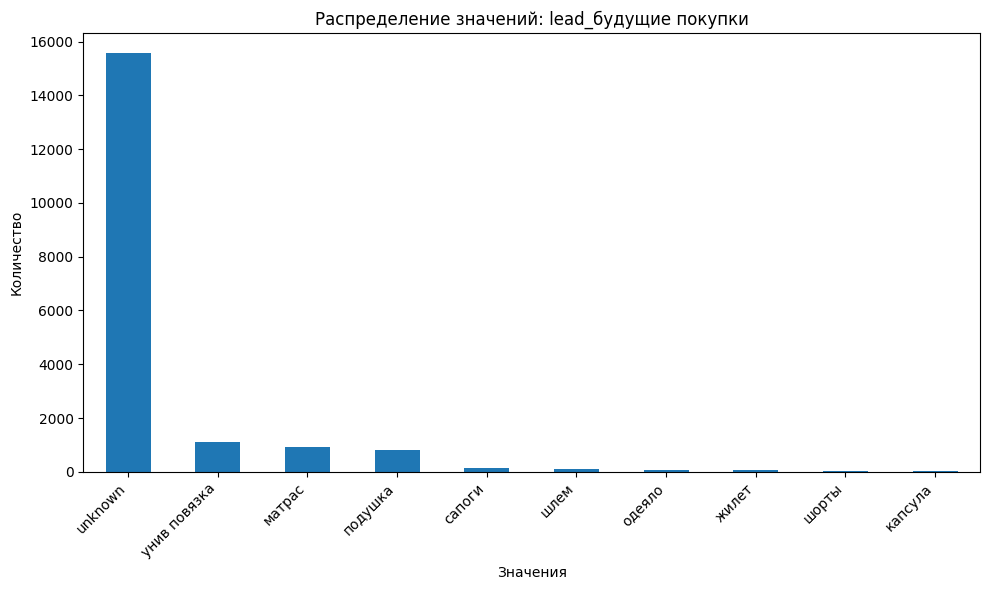

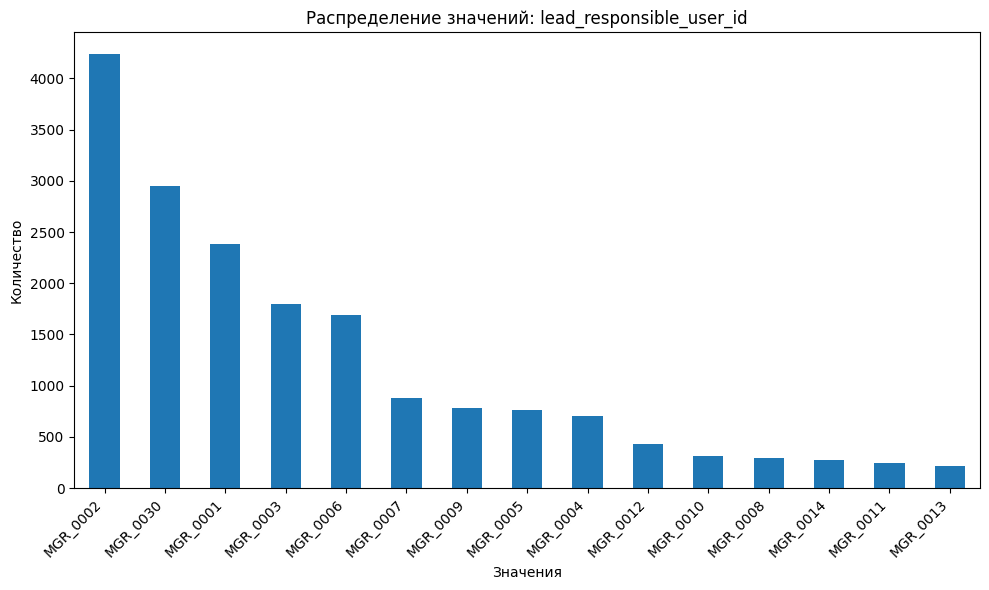

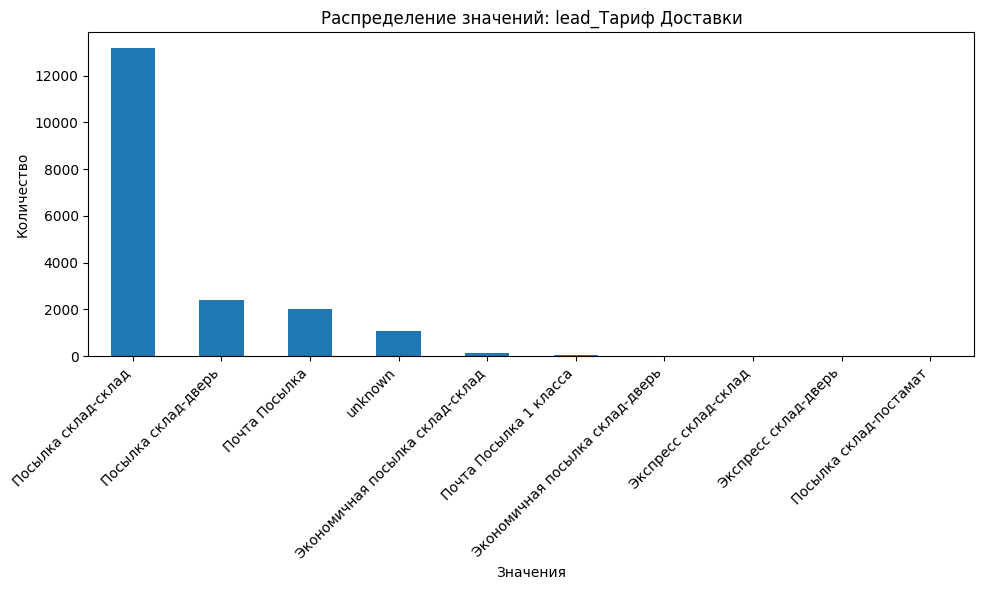

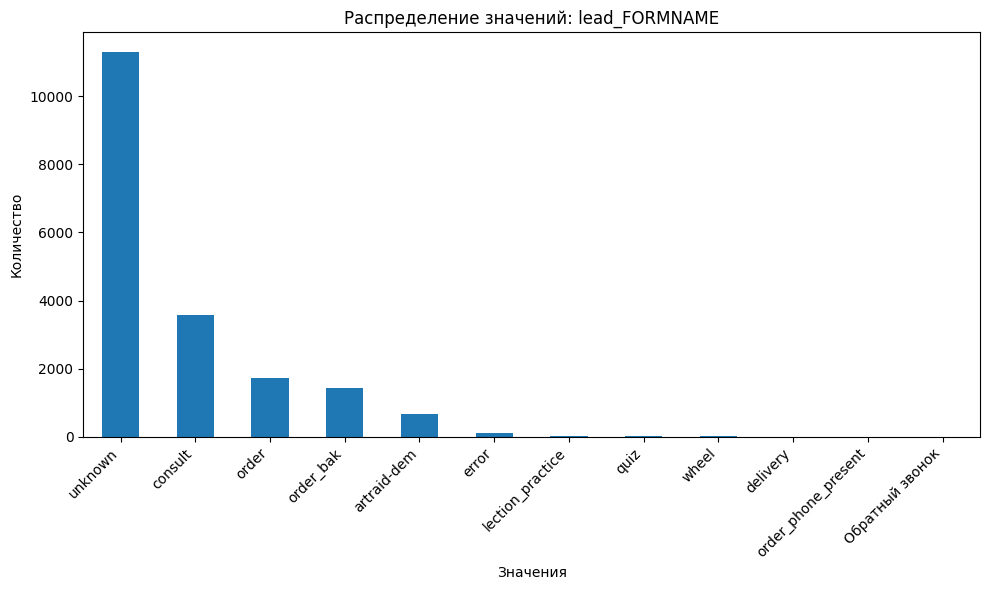

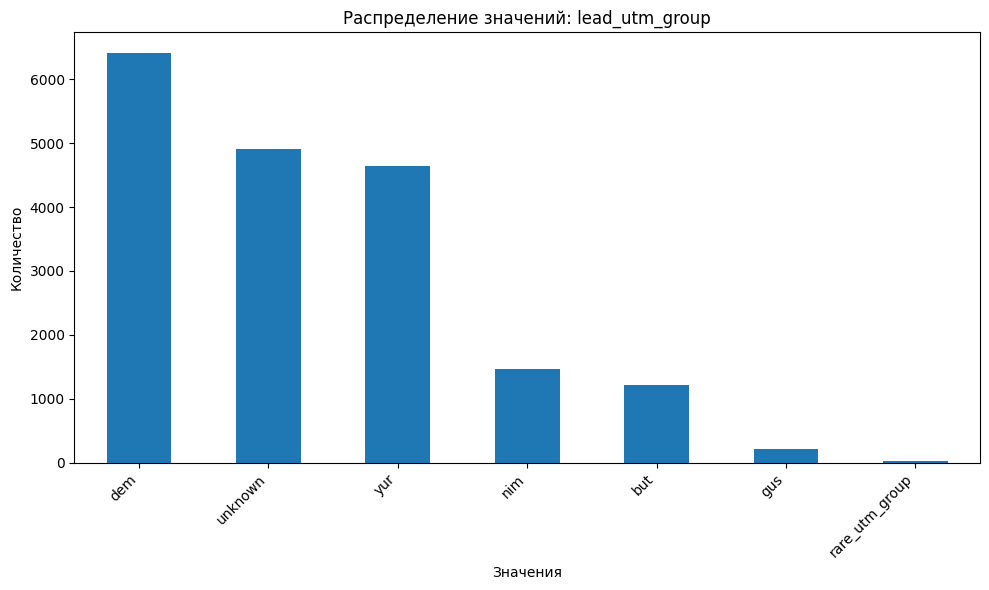

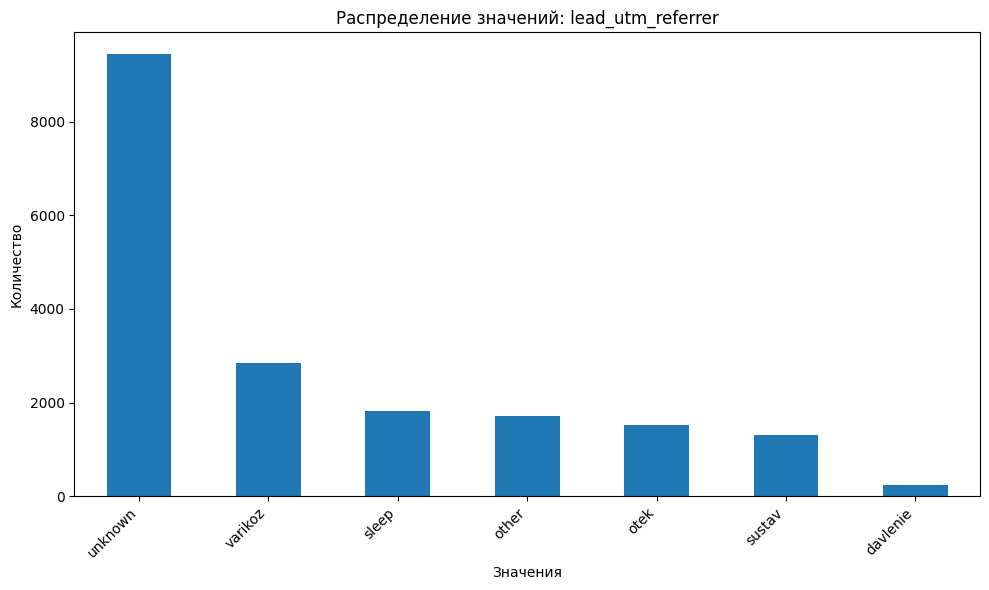

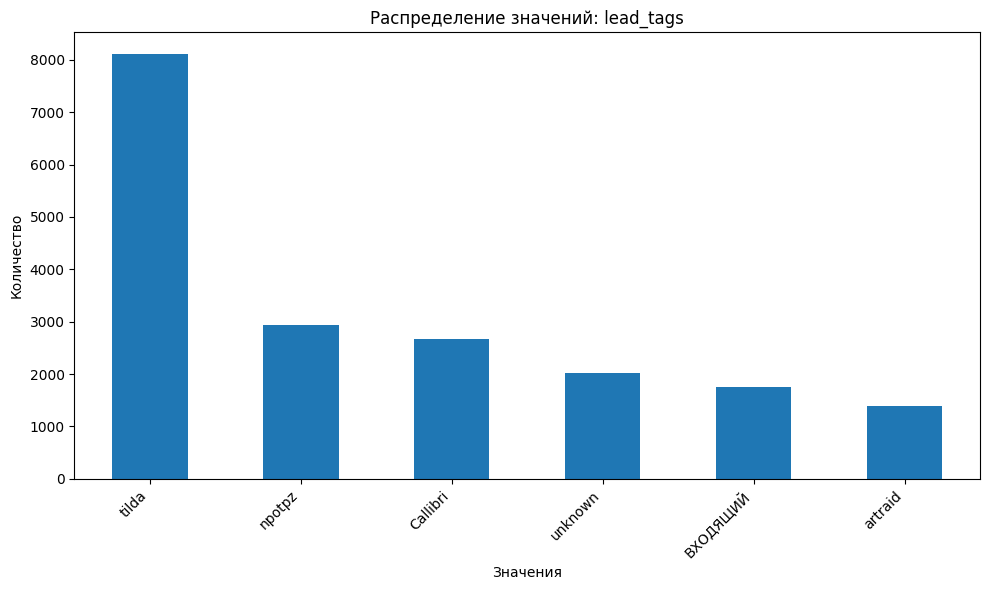

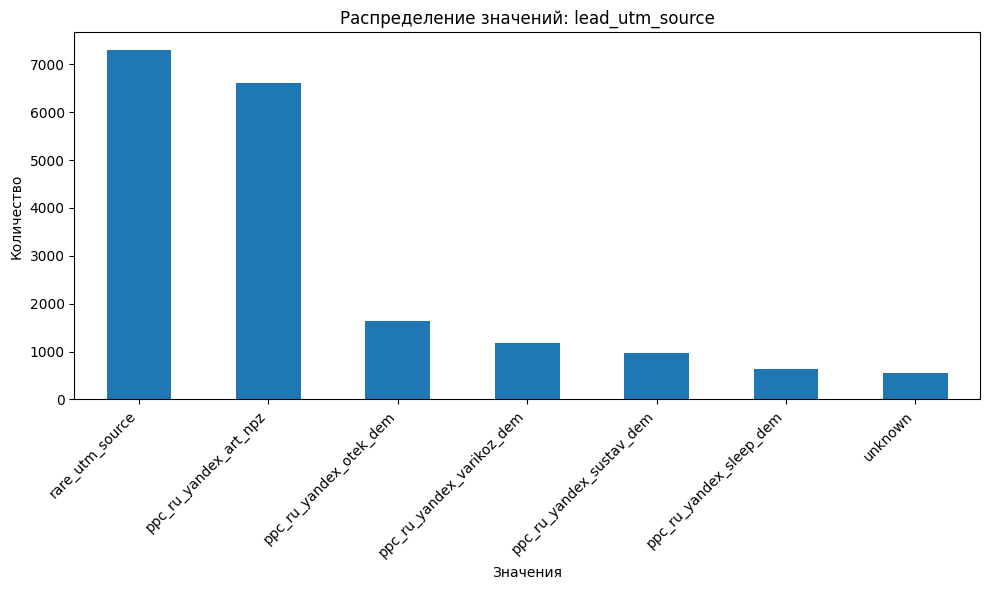

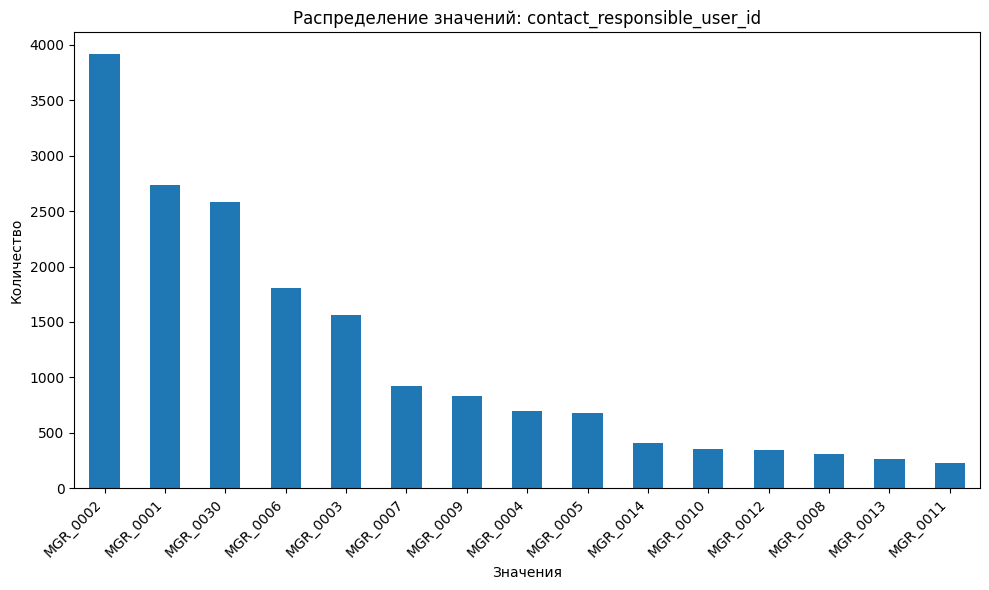

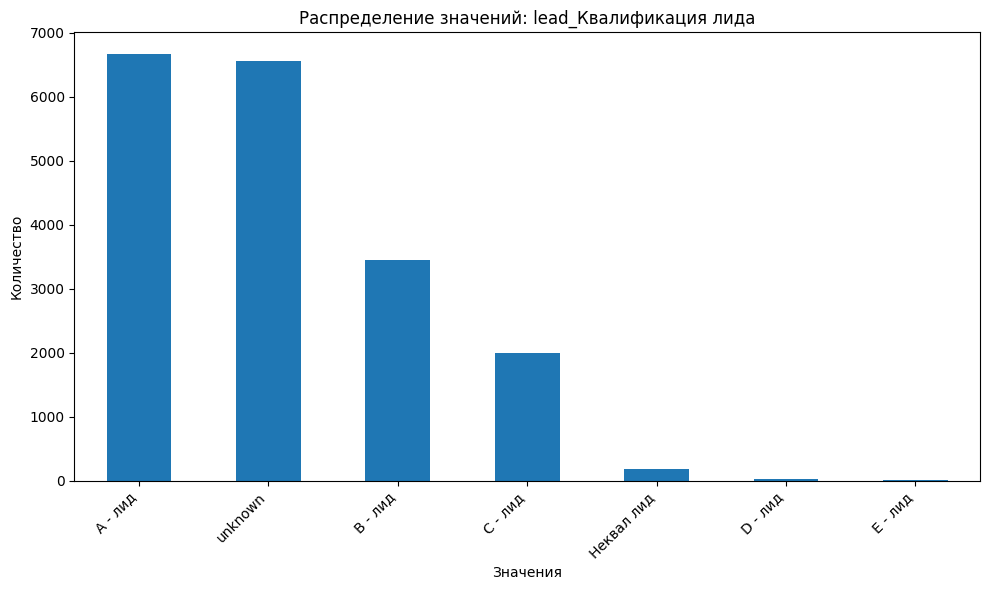

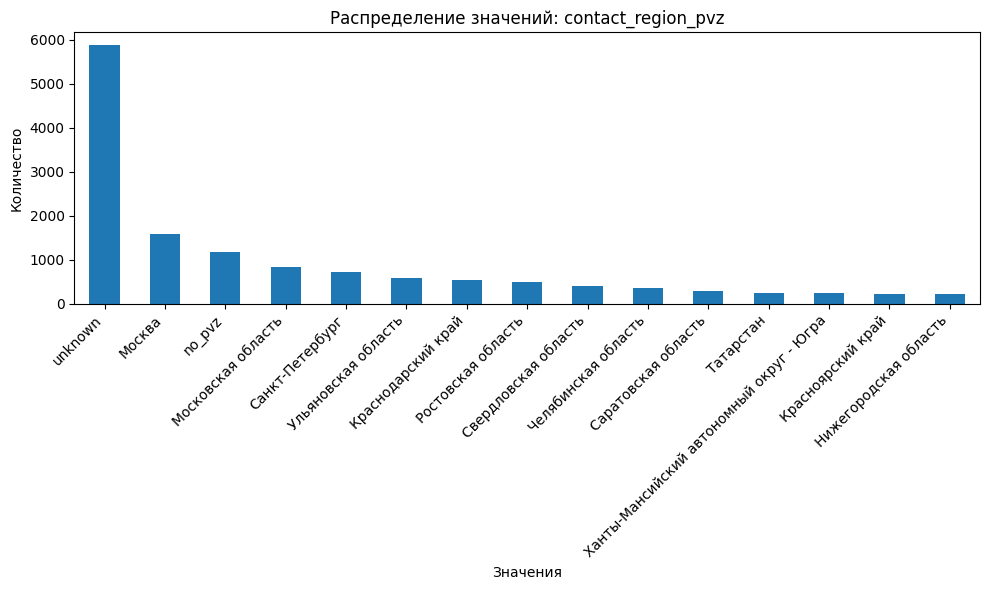

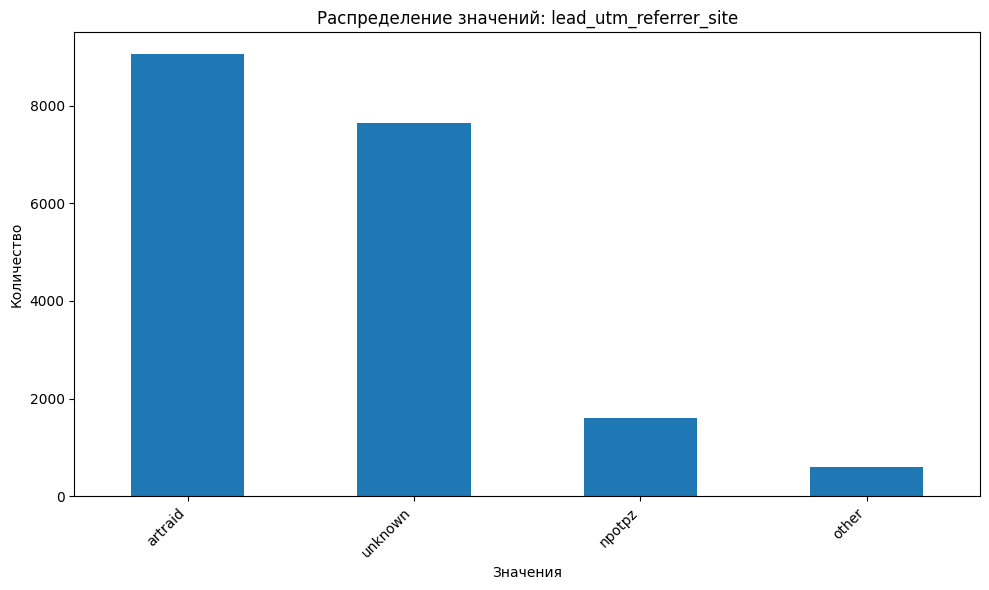

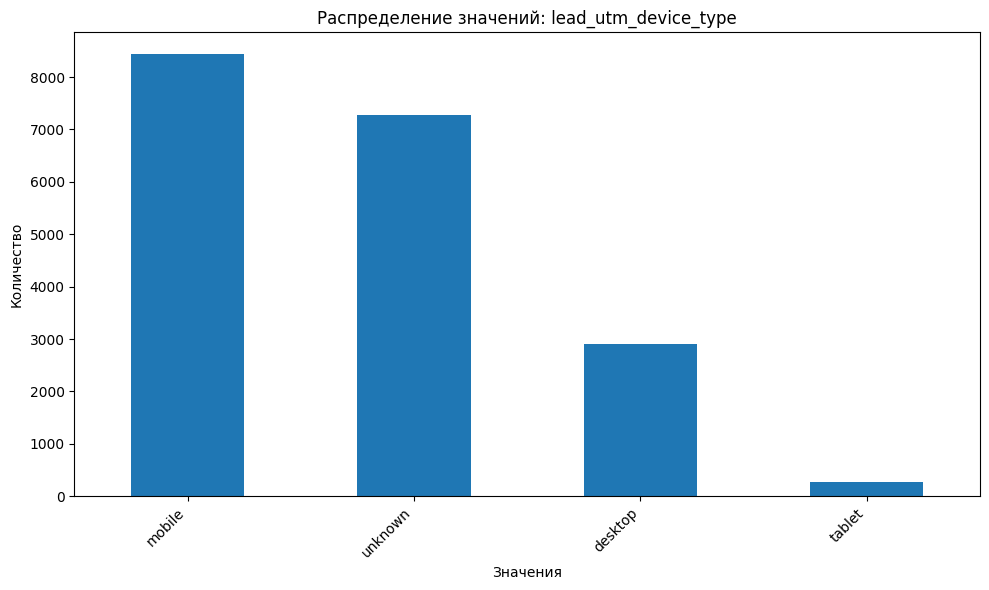

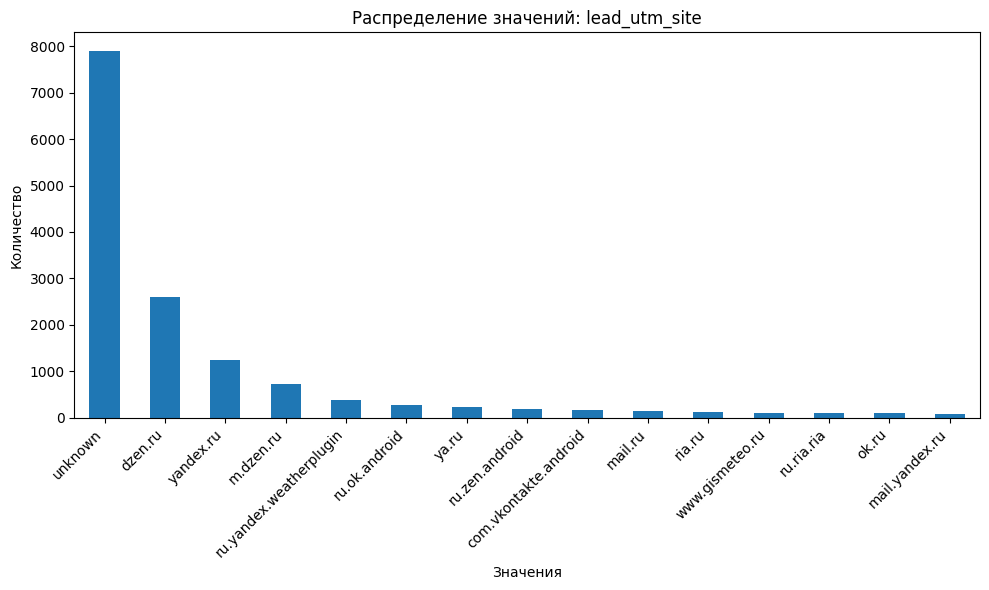

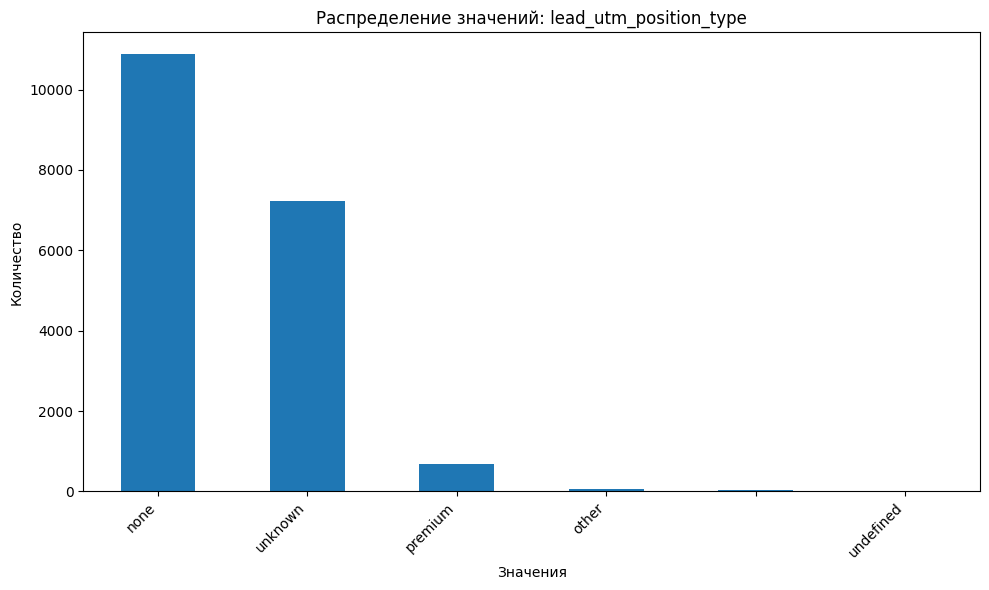

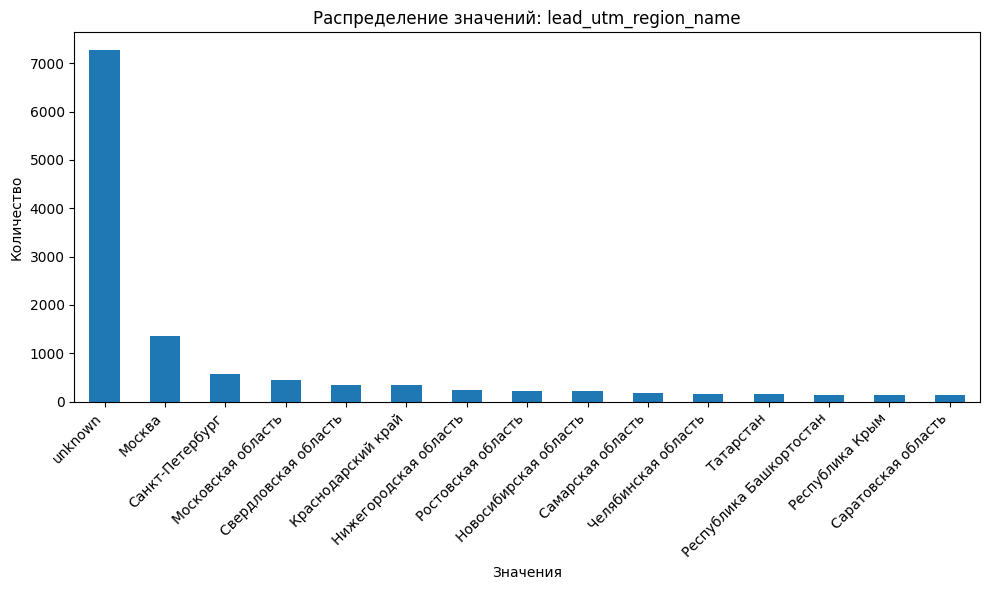

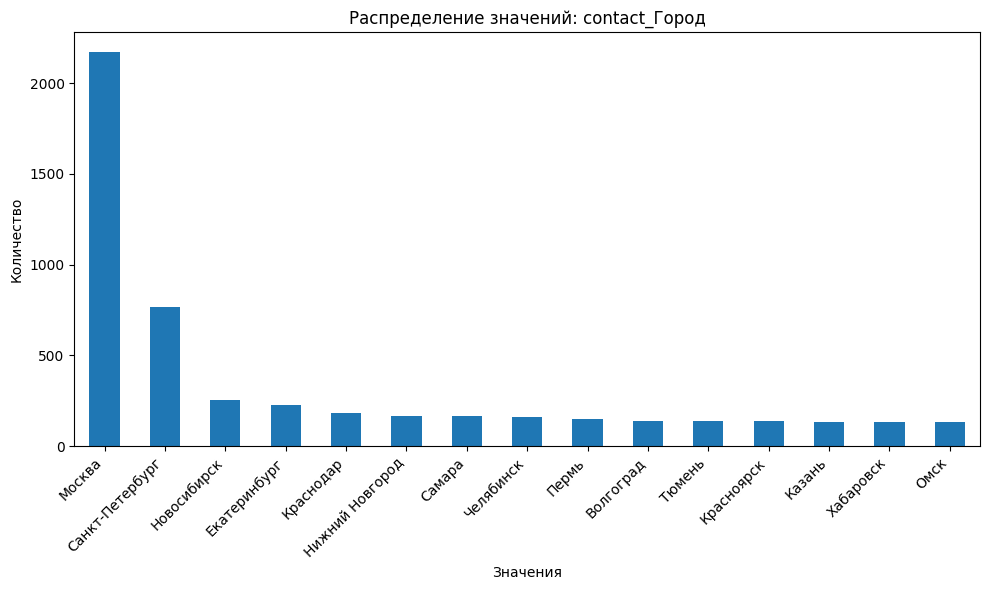

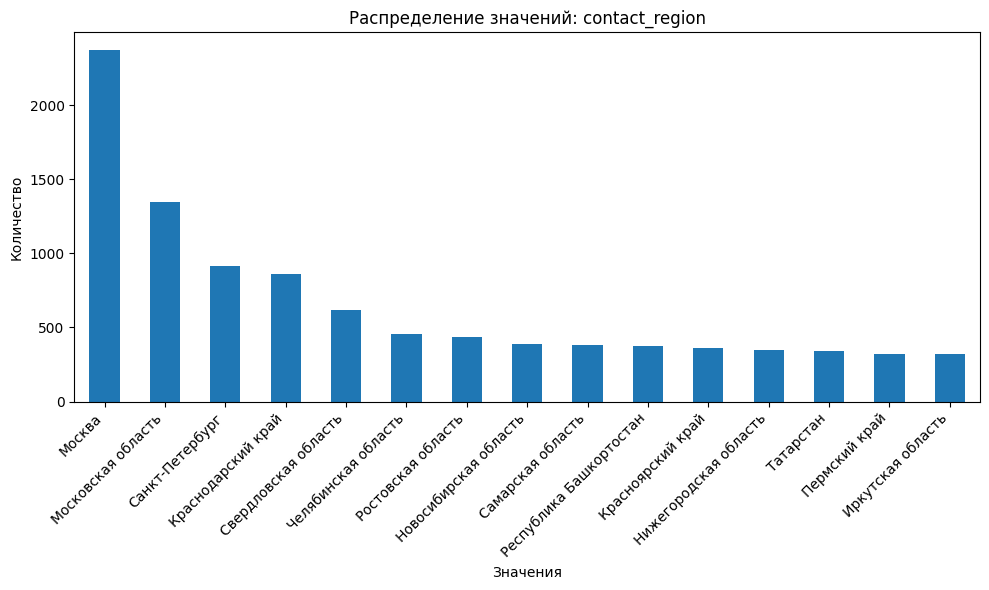

In [266]:
string_columns = block_df.drop(columns=["contact_Код ПВЗ", "lead_utm_content"]).select_dtypes(
    include=["object"], exclude=["datetime64[ns]"]
).columns

for col in string_columns:
    value_counts = block_df[col].value_counts()
    if len(value_counts) > 15:
        value_counts = value_counts.head(15)
    plt.figure(figsize=(10, 6))
    value_counts.plot(kind="bar")
    plt.title(f"Распределение значений: {col}")
    plt.xlabel("Значения")
    plt.ylabel("Количество")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [267]:
res = block_df["lead_будущие покупки"][block_df["lead_будущие покупки"] != "unknown"].value_counts().sum()
print(f"Процент строк для которых указано lead_будущие покупки: {(res / len(block_df)) * 100:.2f}%")

Процент строк для которых указано lead_будущие покупки: 17.63%


In [268]:
block_df = block_df.drop(columns=["lead_будущие покупки"])

In [269]:
top10_ids = block_df["lead_responsible_user_id"].value_counts().index[:10]

block_df["lead_manager_category"] = "rare"
block_df.loc[
    block_df["lead_responsible_user_id"].isin(top10_ids[:5]),
    "lead_manager_category",
] = "top"
block_df.loc[
    block_df["lead_responsible_user_id"].isin(top10_ids[5:10]),
    "lead_manager_category",
] = "middle"

<Axes: xlabel='lead_utm_site'>

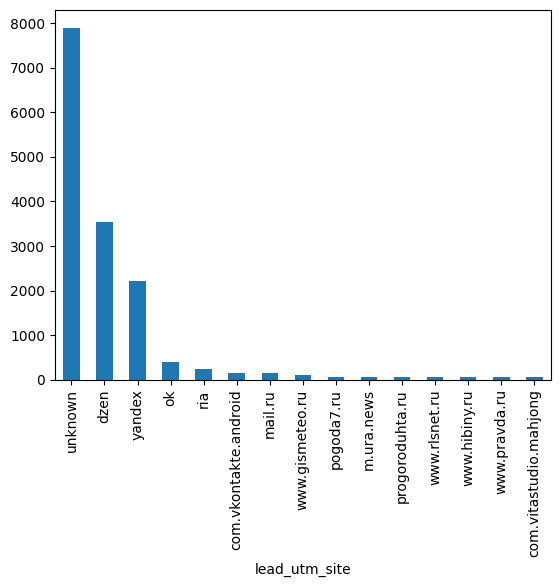

In [270]:
block_df["lead_utm_site"] = block_df["lead_utm_site"].apply(
    lambda x: "yandex"
    if isinstance(x, str)
    and (
        "yandex" in x
        or x.startswith("ya.")
        or x.endswith(".ya")
        or ".ya." in x
    )
    else x
).apply(
    lambda x: "dzen"
    if isinstance(x, str)
    and (
        "dzen" in x
        or x.startswith("zen.")
        or x.endswith(".zen")
        or ".zen." in x
    )
    else x
).apply(
    lambda x: "ok"
    if isinstance(x, str)
    and (
        x.startswith("ok.")
        or x.endswith(".ok")
        or ".ok." in x
    )
    else x
).apply(
    lambda x: "ria"
    if isinstance(x, str)
    and (
        x.startswith("ria.")
        or x.endswith(".ria")
        or ".ria." in x
    )
    else x
)
block_df["lead_utm_site"].value_counts().head(15).plot(kind="bar")

In [271]:
res = block_df["lead_utm_position_type"][
    block_df["lead_utm_position_type"] == "premium"
].value_counts().iloc[0]
print(f"Процент строк с lead_utm_position_type premium: {res / len(block_df):.2f}%")

Процент строк с lead_utm_position_type premium: 0.04%


In [272]:
block_df["lead_rate_is_warehouse_to_warehouse"] = np.where(
    block_df["lead_Тариф Доставки"] == "Посылка склад-склад", 1, 0
)

block_df["lead_formname_has_value"] = np.where(
    block_df["lead_FORMNAME"] != "unknown", 1, 0
)

mask = ~block_df["contact_region_pvz"].isin(["unknown", "no_pvz"])
top15 = block_df.loc[mask, "contact_region_pvz"].value_counts().index[:15]
block_df["contact_region_pvz"] = block_df["contact_region_pvz"].where(
    block_df["contact_region_pvz"].isin(top15), "rare_region"
)

mask = ~block_df["contact_region_pvz"].isin(["unknown", "no_pvz"])
top15 = block_df.loc[mask, "contact_region_pvz"].value_counts().index[:15]
block_df["contact_region_pvz"] = block_df["contact_region_pvz"].where(
    block_df["contact_region_pvz"].isin(top15), "rare_region"
)

top15_regions = (
    block_df["contact_region"]
    .value_counts()
    .head(15)
    .index
)

block_df["contact_region"] = block_df["contact_region"].where(
    block_df["contact_region"].isin(top15_regions),
    "rare_region",
)

top15_cities = (
    block_df["contact_Город"]
    .value_counts()
    .head(15)
    .index
)

block_df["contact_Город"] = block_df["contact_Город"].where(
    block_df["contact_Город"].isin(top15_cities),
    "rare_city",
)



mask = ~block_df["lead_utm_site"].isin(["unknown"])
top15 = block_df.loc[mask, "lead_utm_site"].value_counts().index[:15]
block_df["lead_utm_site"] = block_df["lead_utm_site"].where(
    block_df["lead_utm_site"].isin(top15), "rare_site"
)

mask = ~block_df["lead_utm_region_name"].isin(["unknown"])
top15 = block_df.loc[mask, "lead_utm_region_name"].value_counts().index[:15]
block_df["lead_utm_region_name"] = block_df["lead_utm_region_name"].where(
    block_df["lead_utm_region_name"].isin(top15), "rare_region"
)

block_df = block_df.drop(columns=["lead_Тариф Доставки", "lead_FORMNAME", "lead_utm_position_type"])

In [273]:
block_df.select_dtypes(include=["datetime64[ns]"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 3 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   lead_Дата создания сделки         8286 non-null   datetime64[ns]
 1   sale_date                         18887 non-null  datetime64[ns]
 2   lead_Дата получения денег на Р/С  11476 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 442.8 KB


In [274]:
block_df = pd.concat([block_df, df["buyout_flag"]], axis=1)

In [275]:
block_df["buyout_flag"] = (
    block_df["buyout_flag"]
    .convert_dtypes()
    .fillna(False)
    .astype("int16")
)

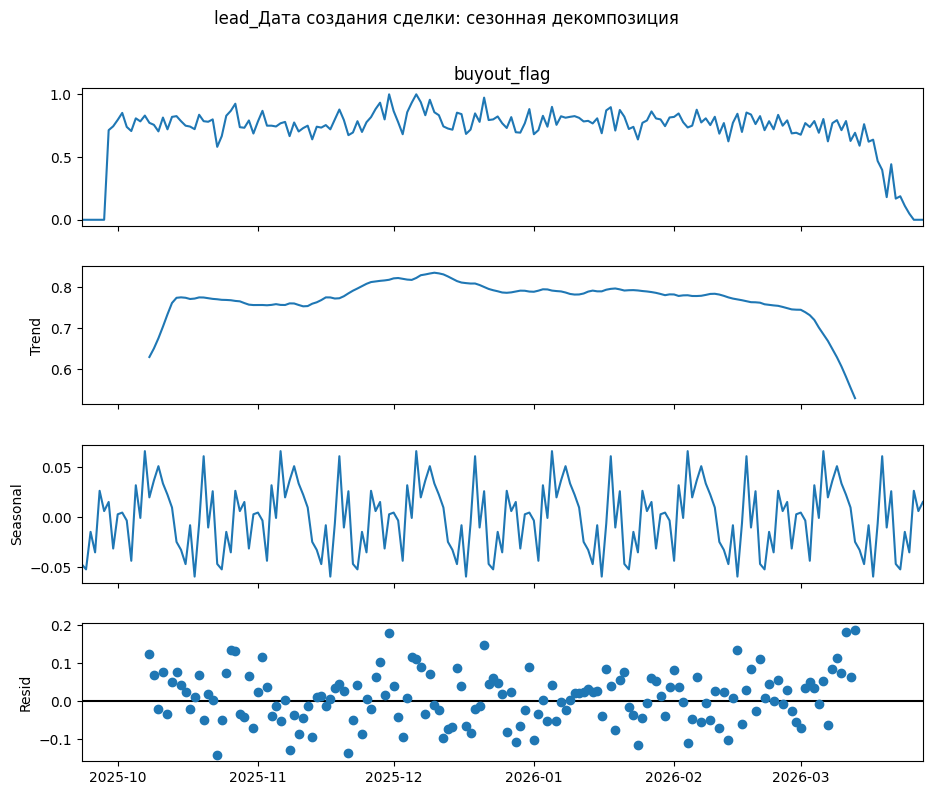

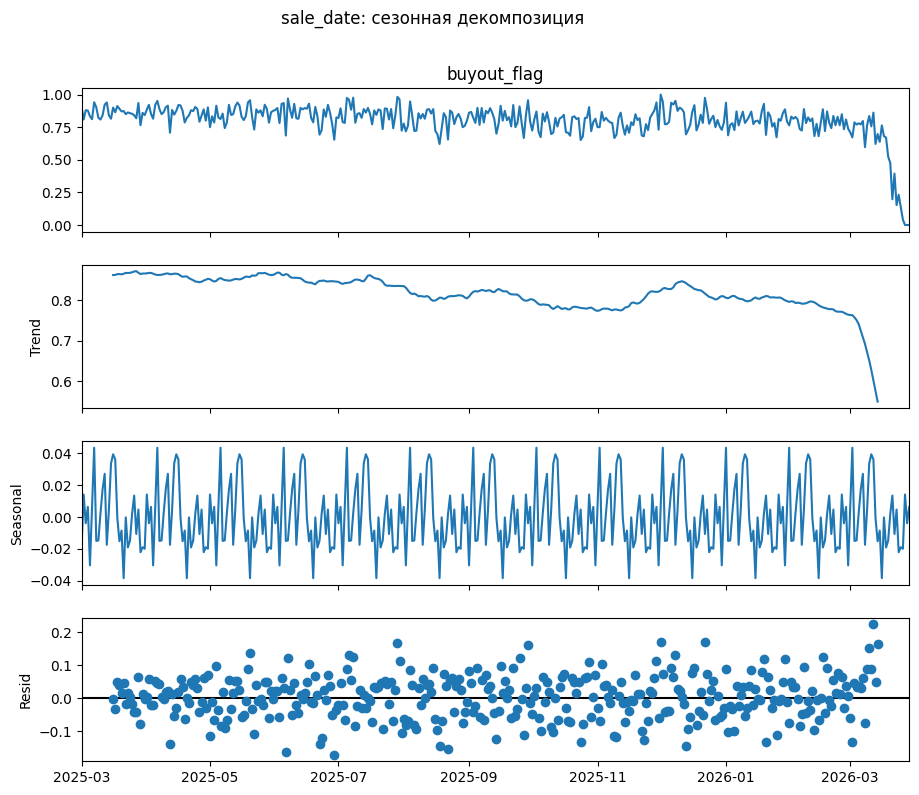

In [276]:
for col in ["lead_Дата создания сделки", "sale_date"]:
    ts = block_df.set_index(col)["buyout_flag"].resample("D").mean().fillna(0)
    decomposition = seasonal_decompose(ts, model="additive", period=30)
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle(f"{col}: сезонная декомпозиция", y=1.02)
    plt.show()

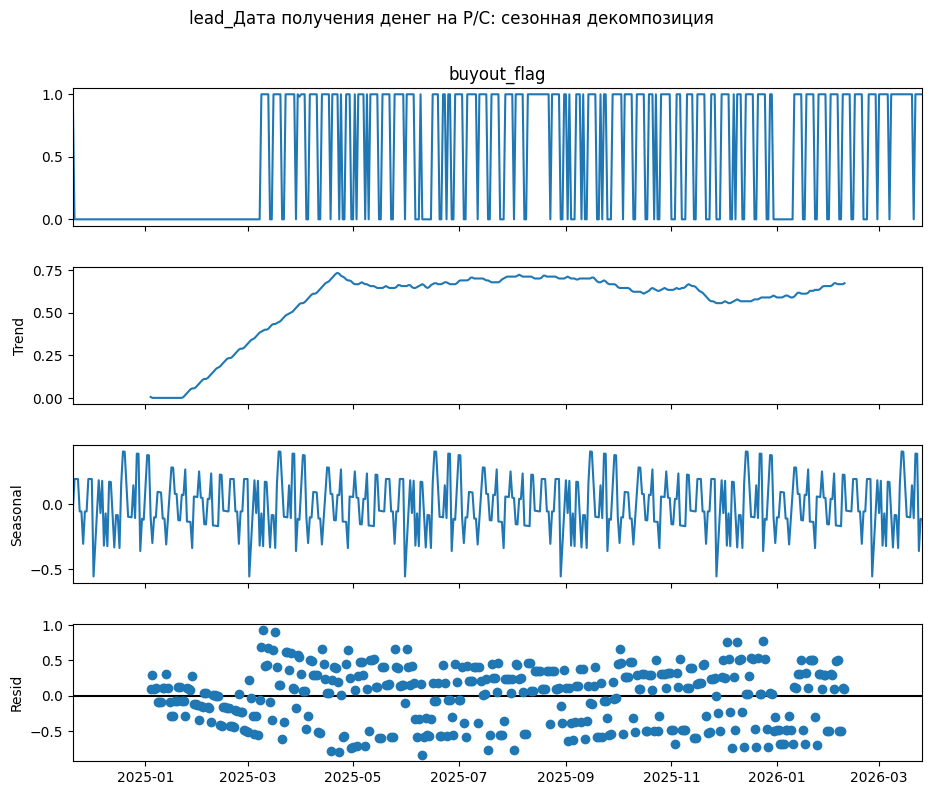

In [277]:
for col in ["lead_Дата получения денег на Р/С"]:
    ts = block_df.set_index(col)["buyout_flag"].resample("D").mean().fillna(0)
    decomposition = seasonal_decompose(ts, model="additive", period=90)
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle(f"{col}: сезонная декомпозиция", y=1.02)
    plt.show()

In [278]:
block_df["lead_has_creation_date"] = (
    block_df["lead_Дата создания сделки"].notna().astype(int)
)

block_df["lead_creation_date_week"] = (
    block_df["lead_Дата создания сделки"].dt.isocalendar().week.astype("Int64")
)
block_df["lead_creation_date_month"] = block_df[
    "lead_Дата создания сделки"
].dt.month.astype("Int64")
block_df["lead_creation_date_quarter"] = block_df[
    "lead_Дата создания сделки"
].dt.quarter.astype("Int64")
block_df["lead_creation_date_dayofweek"] = block_df[
    "lead_Дата создания сделки"
].dt.dayofweek.astype("Int64")

day = block_df["lead_Дата создания сделки"].dt.day
block_df["lead_creation_date_sin"] = np.sin(2 * np.pi * day / 30)
block_df["lead_creation_date_cos"] = np.cos(2 * np.pi * day / 30)

date_cols = [
    "lead_creation_date_week",
    "lead_creation_date_month",
    "lead_creation_date_quarter",
    "lead_creation_date_dayofweek",
    "lead_creation_date_sin",
    "lead_creation_date_cos",
]

for col in date_cols:
    block_df[col] = block_df[col].fillna(-1)

In [279]:
block_df["sale_date_month"] = block_df["sale_date"].dt.month
block_df["sale_date_quarter"] = block_df["sale_date"].dt.quarter
block_df["sale_date_dayofweek"] = block_df["sale_date"].dt.dayofweek
block_df["sale_date_week"] = block_df["sale_date"].dt.isocalendar().week

day = block_df["sale_date"].dt.day
block_df["sale_date_sin"] = np.sin(2 * np.pi * day / 30)
block_df["sale_date_cos"] = np.cos(2 * np.pi * day / 30)


original_index = block_df.index
block_df = block_df.sort_values("sale_date")
block_df["buyout_flag_lag30"] = block_df["buyout_flag"].shift(30)
block_df["buyout_flag_lag60"] = block_df["buyout_flag"].shift(60)
block_df["buyout_flag_ma30"] = (
    block_df["buyout_flag"].rolling(30, min_periods=1).mean()
)

block_df = block_df.reindex(original_index)

In [280]:
block_df = block_df.drop(columns=["lead_Дата создания сделки", "lead_Дата получения денег на Р/С", "buyout_flag", "outcome_unknown"])

In [281]:
block_df = block_df.rename(
    columns={
        "contact_Код ПВЗ": "contact_pvz_code",
        "lead_Вес (грамм)*": "lead_weight_gm",
    }
)

In [282]:
block_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 49 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   row_id                               18887 non-null  int64         
 1   contact_pvz_code                     18887 non-null  object        
 2   lead_weight_gm                       18887 non-null  float64       
 3   lead_responsible_user_id             18887 non-null  object        
 4   lead_utm_content                     18887 non-null  object        
 5   contact_LTV                          18887 non-null  float64       
 6   sale_date                            18887 non-null  datetime64[ns]
 7   lead_utm_group                       18887 non-null  object        
 8   lead_utm_referrer                    18887 non-null  object        
 9   lead_tags                            18887 non-null  object        
 10  lead_utm_s

In [283]:
block_df = pd.concat(
    [block_df, df[["lead_ROISTAT_URL", "lead_URL", "lead_URL страницы"]]], axis=1
)

In [284]:
block_df[["lead_ROISTAT_URL", "lead_URL", "lead_URL страницы"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   lead_ROISTAT_URL   3720 non-null   object
 1   lead_URL           1364 non-null   object
 2   lead_URL страницы  4045 non-null   object
dtypes: object(3)
memory usage: 442.8+ KB


In [285]:
block_df = block_df.drop(columns=["lead_ROISTAT_URL", "lead_URL", "lead_URL страницы", "contact_responsible_user_id"])

In [287]:
block_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   row_id                               18887 non-null  int64         
 1   contact_pvz_code                     18887 non-null  object        
 2   lead_weight_gm                       18887 non-null  float64       
 3   lead_responsible_user_id             18887 non-null  object        
 4   lead_utm_content                     18887 non-null  object        
 5   contact_LTV                          18887 non-null  float64       
 6   sale_date                            18887 non-null  datetime64[ns]
 7   lead_utm_group                       18887 non-null  object        
 8   lead_utm_referrer                    18887 non-null  object        
 9   lead_tags                            18887 non-null  object        
 10  lead_utm_s

In [288]:
# Путь для сохранения обработанного DataFrame
OUTPUT_FILE = OUTPUT_DIR / "features_group_2_processed.csv"

# Сохраняем DataFrame в CSV-файл
block_df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

## Функции обработки признаков

Названия функций совпадают с private-методами из `feature_processor.py`.

In [877]:
# def _add_width_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
#     if "lead_Ширина" not in block_df.columns:
#         return
#     series = pd.to_numeric(block_df["lead_Ширина"], errors="coerce")
#     result["lead_Ширина"] = series.fillna(series.median())


# def _add_linear_height_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
#     if "lead_Линейная высота (см)" not in block_df.columns:
#         return
#     series = pd.to_numeric(block_df["lead_Линейная высота (см)"], errors="coerce")
#     result["lead_Линейная высота (см)"] = series.fillna(series.median())
#     result["lead_Линейная высота (см)__was_missing"] = series.isna().astype(int)


# def _add_payment_type_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
#     if "lead_Вид оплаты" not in block_df.columns:
#         return
#     series = (
#         block_df["lead_Вид оплаты"]
#         .astype("string")
#         .fillna("UNKNOWN")
#         .str.strip()
#         .str.lower()
#     )
#     result["lead_Вид оплаты"] = series.replace({"": "unknown"}).astype(str)


# def _add_returned_ts_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
#     if "returned_ts" not in block_df.columns:
#         return
#     ts = pd.to_datetime(block_df["returned_ts"], errors="coerce")
#     result["returned_ts"] = ts.astype("string")
#     result["returned_ts__is_present"] = ts.notna().astype(int)


# def _add_delivery_service_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
#     if "lead_Служба доставки" not in block_df.columns:
#         return
#     series = (
#         block_df["lead_Служба доставки"]
#         .astype("string")
#         .fillna("UNKNOWN")
#         .str.strip()
#     )
#     value_counts = series.value_counts(dropna=False)
#     rare_values = value_counts[value_counts < 10].index
#     result["lead_Служба доставки"] = series.replace(list(rare_values), "OTHER").astype(str)


# def _add_default_feature(block_df: pd.DataFrame, result: pd.DataFrame, column: str) -> None:
#     series = block_df[column]
#     if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
#         result[column] = series.fillna("").astype(str)
#     else:
#         result[column] = series

In [878]:
# X_block = pd.DataFrame(index=block_df.index)

# for column in block_df.columns:
#     if column == "lead_Ширина":
#         _add_width_feature(block_df, X_block)
#     elif column == "lead_Линейная высота (см)":
#         _add_linear_height_feature(block_df, X_block)
#     elif column == "lead_Вид оплаты":
#         _add_payment_type_feature(block_df, X_block)
#     elif column == "returned_ts":
#         _add_returned_ts_feature(block_df, X_block)
#     elif column == "lead_Служба доставки":
#         _add_delivery_service_feature(block_df, X_block)
#     else:
#         _add_default_feature(block_df, X_block, column)

# print("Processed shape:", X_block.shape)
# display(X_block.head())

In [879]:
# X_block.to_csv(OUTPUT_DIR / "X_block.csv", index=False)
# feature_spec = create_feature_spec_template(X_block)
# feature_spec.to_csv(OUTPUT_DIR / "feature_spec.csv", index=False)

# print("Saved:")
# print(OUTPUT_DIR / "X_block.csv")
# print(OUTPUT_DIR / "feature_spec.csv")